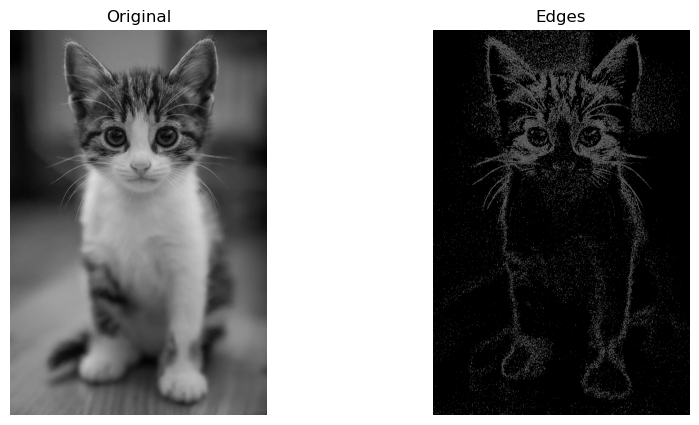

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def custom_canny(image_path, low_thresh=50, high_thresh=150):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found or could not be loaded.")
    
    edges = cv2.Canny(image, low_thresh, high_thresh)
    return image, edges

def display_results(image, edges):
    plt.figure(figsize=(10, 5))
    for i, (img, title) in enumerate(zip([image, edges], ['Original', 'Edges'])):
        plt.subplot(1, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = 'onur-binay-E18nZ_OHh04-unsplash.jpg' # Replace with your actual image path
image, edges = custom_canny(image_path)
display_results(image, edges)


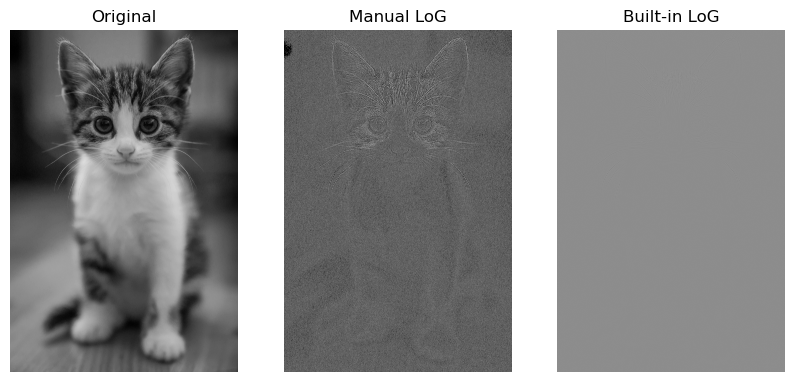

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def laplacian_of_gaussian(image_path, ksize=5, sigma=1.4):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found or could not be loaded.")
    
    gaussian_blur = ndimage.gaussian_filter(image, sigma=sigma)
    laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
    log_manual = ndimage.convolve(gaussian_blur, laplacian_kernel)
    log_builtin = cv2.Laplacian(cv2.GaussianBlur(image, (ksize, ksize), sigma), cv2.CV_64F)
    
    return image, log_manual, log_builtin

def display_results(image, log_manual, log_builtin):
    plt.figure(figsize=(10, 5))
    titles = ['Original', 'Manual LoG', 'Built-in LoG']
    for i, (img, title) in enumerate(zip([image, log_manual, log_builtin], titles)):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = 'onur-binay-E18nZ_OHh04-unsplash.jpg'  # Replace with your actual image path
image, log_manual, log_builtin = laplacian_of_gaussian(image_path)
display_results(image, log_manual, log_builtin)


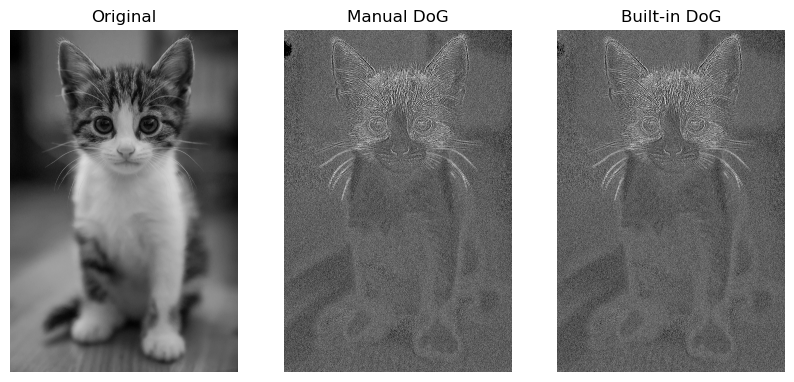

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def difference_of_gaussian(image_path, sigma1=1, sigma2=3):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found or could not be loaded.")
    
    gaussian1, gaussian2 = ndimage.gaussian_filter(image, sigma1), ndimage.gaussian_filter(image, sigma2)
    dog_manual = gaussian1 - gaussian2
    dog_builtin = cv2.GaussianBlur(image, (0, 0), sigma1) - cv2.GaussianBlur(image, (0, 0), sigma2)
    
    return image, dog_manual, dog_builtin

def display_results(image, dog_manual, dog_builtin):
    plt.figure(figsize=(10, 5))
    titles = ['Original', 'Manual DoG', 'Built-in DoG']
    for i, (img, title) in enumerate(zip([image, dog_manual, dog_builtin], titles)):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = 'onur-binay-E18nZ_OHh04-unsplash.jpg'  # Replace with your actual image path
image, dog_manual, dog_builtin = difference_of_gaussian(image_path)
display_results(image, dog_manual, dog_builtin)


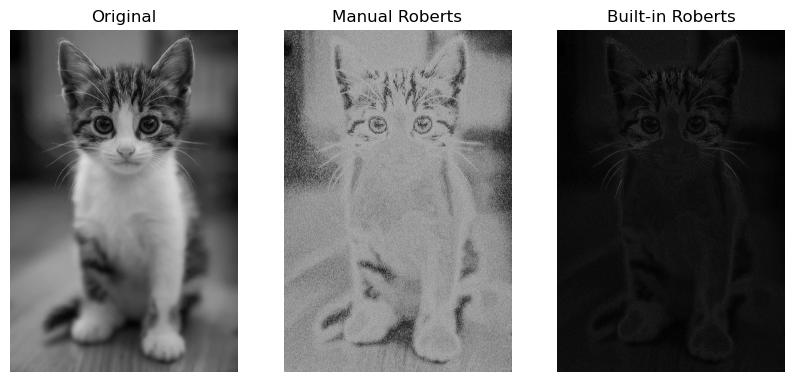

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def roberts_filter(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found or could not be loaded.")
    
    kernel_x, kernel_y = np.array([[1, 0], [0, -1]]), np.array([[0, 1], [-1, 0]])
    grad_x = ndimage.convolve(image, kernel_x)
    grad_y = ndimage.convolve(image, kernel_y)
    edges_manual = np.sqrt(grad_x**2 + grad_y**2).astype(np.uint8)
    
    edges_builtin = np.sqrt(cv2.filter2D(image, cv2.CV_64F, kernel_x)**2 + 
                            cv2.filter2D(image, cv2.CV_64F, kernel_y)**2)
    edges_builtin = cv2.normalize(edges_builtin, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return image, edges_manual, edges_builtin

def display_results(image, edges_manual, edges_builtin):
    plt.figure(figsize=(10, 5))
    titles = ['Original', 'Manual Roberts', 'Built-in Roberts']
    for i, (img, title) in enumerate(zip([image, edges_manual, edges_builtin], titles)):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = 'onur-binay-E18nZ_OHh04-unsplash.jpg'  # Replace with your image path
image, edges_manual, edges_builtin = roberts_filter(image_path)
display_results(image, edges_manual, edges_builtin)


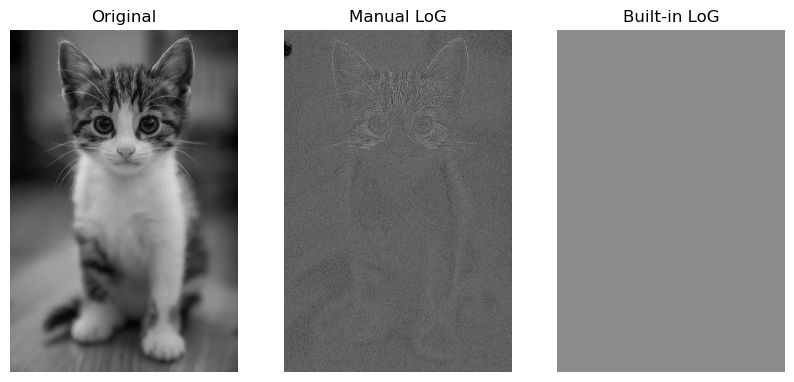

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def laplacian_of_gaussian(image_path, ksize=5, sigma=1.4):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found or could not be loaded.")
    
    gaussian_blur = ndimage.gaussian_filter(image, sigma=sigma)
    laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
    log_manual = ndimage.convolve(gaussian_blur, laplacian_kernel)
    log_manual = cv2.normalize(log_manual, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    log_builtin = cv2.Laplacian(cv2.GaussianBlur(image, (ksize, ksize), sigma), cv2.CV_64F)
    log_builtin = cv2.normalize(log_builtin, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return image, log_manual, log_builtin

def display_results(image, log_manual, log_builtin):
    plt.figure(figsize=(10, 5))
    titles = ['Original', 'Manual LoG', 'Built-in LoG']
    for i, (img, title) in enumerate(zip([image, log_manual, log_builtin], titles)):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = 'onur-binay-E18nZ_OHh04-unsplash.jpg'  # Replace with your actual image path
image, log_manual, log_builtin = laplacian_of_gaussian(image_path)
display_results(image, log_manual, log_builtin)


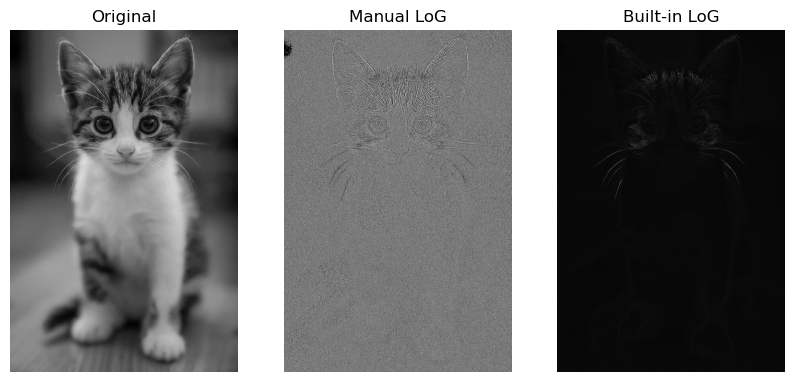

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def laplacian_of_gaussian(image_path, ksize=5, sigma=1.4):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found or could not be loaded.")
    
    gaussian_blur = ndimage.gaussian_filter(image, sigma=sigma)

    # Using a larger Laplacian kernel for better edge detection
    laplacian_kernel = np.array([
        [0,  0,  1,  0,  0],
        [0,  1,  2,  1,  0],
        [1,  2, -16, 2,  1],
        [0,  1,  2,  1,  0],
        [0,  0,  1,  0,  0]
    ])
    
    log_manual = ndimage.convolve(gaussian_blur, laplacian_kernel)
    
    # Convert to absolute values and normalize for visibility
    log_manual = np.abs(log_manual)
    log_manual = cv2.normalize(log_manual, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    log_builtin = cv2.Laplacian(cv2.GaussianBlur(image, (ksize, ksize), sigma), cv2.CV_64F)
    log_builtin = np.abs(log_builtin)  # Convert to absolute values
    log_builtin = cv2.normalize(log_builtin, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    return image, log_manual, log_builtin

def display_results(image, log_manual, log_builtin):
    plt.figure(figsize=(10, 5))
    titles = ['Original', 'Manual LoG', 'Built-in LoG']
    for i, (img, title) in enumerate(zip([image, log_manual, log_builtin], titles)):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = 'onur-binay-E18nZ_OHh04-unsplash.jpg'  # Replace with your actual image path
image, log_manual, log_builtin = laplacian_of_gaussian(image_path)
display_results(image, log_manual, log_builtin)


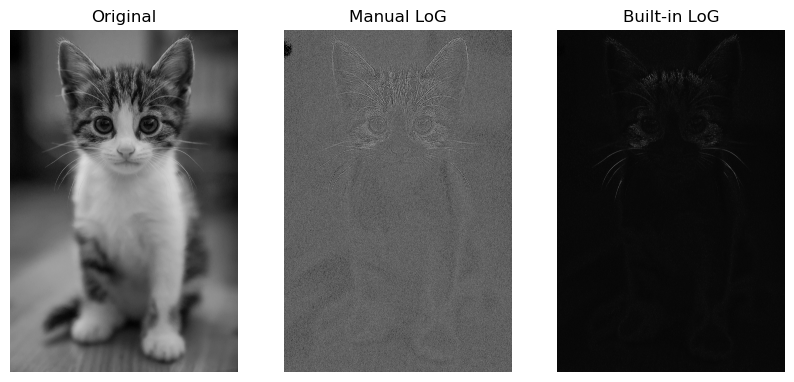

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def laplacian_of_gaussian(image_path, ksize=5, sigma=1.4):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found or could not be loaded.")
    
    # Manual LoG
    gaussian_blur = ndimage.gaussian_filter(image, sigma=sigma)
    laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
    log_manual = ndimage.convolve(gaussian_blur, laplacian_kernel)
    log_manual = cv2.normalize(log_manual, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Built-in LoG
    blurred = cv2.GaussianBlur(image, (ksize, ksize), sigma)
    log_builtin = cv2.Laplacian(blurred, cv2.CV_64F)
    log_builtin = cv2.convertScaleAbs(log_builtin)  # Convert to absolute values for better visibility
    
    return image, log_manual, log_builtin

def display_results(image, log_manual, log_builtin):
    plt.figure(figsize=(10, 5))
    titles = ['Original', 'Manual LoG', 'Built-in LoG']
    for i, (img, title) in enumerate(zip([image, log_manual, log_builtin], titles)):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = 'onur-binay-E18nZ_OHh04-unsplash.jpg'  # Replace with your actual image path
image, log_manual, log_builtin = laplacian_of_gaussian(image_path)
display_results(image, log_manual, log_builtin)
